# Monthly Solar Radiation Plot 2005 and 2006

This notebook loads a combined monthly solar radiation CSV and plots **FLUXNET** versus **GRIDMET** as side-by-side bar charts.


## 1. Imports


In [1]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set working directory to project root
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())

# ---------------------------------------------------------------------------
# Data paths (relative to project root)
# ---------------------------------------------------------------------------
DATA_ROOT = "./data"

CSV_2005 = f'{DATA_ROOT}/monthly_SW_FlexNet_vs_GridMET_2005.csv'
CSV_2006 = f'{DATA_ROOT}/monthly_SW_FlexNet_vs_GridMET_2006.csv'

# Verify files exist
for path in [CSV_2005, CSV_2006]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {path}")

Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main
  [OK] ./data/monthly_SW_FlexNet_vs_GridMET_2005.csv
  [OK] ./data/monthly_SW_FlexNet_vs_GridMET_2006.csv


## 2. Plot settings and helper function


In [2]:
BAR_WIDTH = 0.35
COLOR_FLUX = "#4B0082"   # purple
COLOR_GRID = "#FFD700"   # yellow

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def load_monthly_solar_csv(input_csv):
    """Load and clean the combined monthly solar radiation CSV."""
    df = pd.read_csv(input_csv)

    # Make sure expected numeric columns are numeric
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df["FlexNet_MJ_m2"] = pd.to_numeric(df["FlexNet_MJ_m2"], errors="coerce")
    df["GridMET_MJ_m2"] = pd.to_numeric(df["GridMET_MJ_m2"], errors="coerce")

    # Keep valid months only and sort them
    df = df[df["Month"].between(1, 12)].copy()
    df = df.sort_values("Month").reset_index(drop=True)

    # Create month labels
    df["Month_Label"] = df["Month"].astype(int).apply(lambda m: MONTH_LABELS[m - 1])

    return df


def plot_monthly_solar_radiation(input_csv, year):
    """Plot monthly solar radiation totals for FLUXNET and GRIDMET."""
    df = load_monthly_solar_csv(input_csv)

    months = np.arange(1, len(df) + 1)

    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.bar(
        months - BAR_WIDTH / 2,
        df["FlexNet_MJ_m2"],
        width=BAR_WIDTH,
        color=COLOR_FLUX,
        label="FLUXNET",
        edgecolor="black",
        linewidth=0.5,
    )

    ax.bar(
        months + BAR_WIDTH / 2,
        df["GridMET_MJ_m2"],
        width=BAR_WIDTH,
        color=COLOR_GRID,
        label="GRIDMET",
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_xticks(months)
    ax.set_xticklabels(df["Month_Label"], rotation=45, ha="right")
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("Solar Radiation (MJ m$^{-2}$)", fontsize=12)
    ax.set_title(
        f"{year} — Monthly Solar Radiation Totals",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.legend(loc="upper right", frameon=False, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

## 3. : 2005 plot


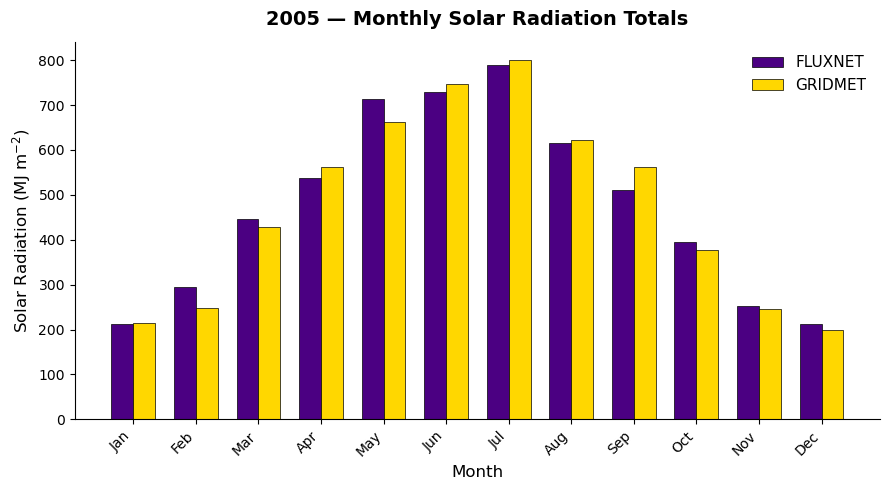

In [3]:
plot_monthly_solar_radiation(CSV_2005, 2005)

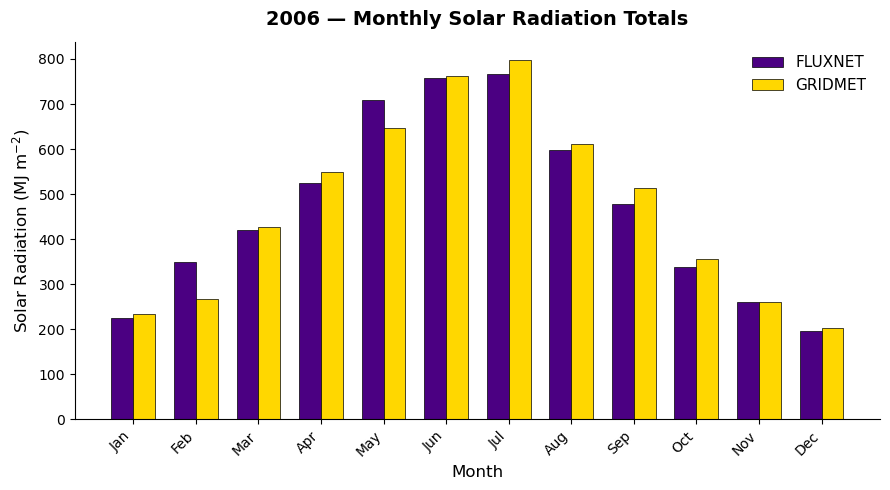

In [5]:
plot_monthly_solar_radiation(CSV_2006, 2006)